In [225]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [226]:
# ============================================================
# Model registry: single source of truth for every forecast series.
# Add or remove a model HERE and it flows through all tables & plots below.
# ============================================================
# Each entry: label -> dict(pred, obs, color, marker, in_common)
#   pred/obs    : CSV basenames in ../../data
#   color/marker: styling for the trajectory & per-country plots
#   in_common   : whether the model joins the shared-grid intersection used by the
#                 headline RMSE tables. Schmertmann only forecasts a restricted set
#                 of cohorts (see the diagnostic cell), so it is scored separately
#                 and kept OUT of the common grid -- matching the original notebook.
#
# The three DL series:
#   'DL square'        -- tuned run on Lexis-square RR data (ACY rates)
#   'DL parallelogram' -- tuned run on vertical-parallelogram VV data (ARDY rates)
#   'DL (prev)'        -- earlier pre-tuning fewer_ages refit, kept for reference
# NOTE: each DL variant is scored against ITS OWN observed file. square (ACY) and
# parallelogram (ARDY) measure different quantities, so their observed rates differ
# -- never score one against the other's obs.
MODEL_REGISTRY = {
    'LeeCarter':        dict(pred='lee2_forecasts_cohort',                obs='lee2_obs_cohort',                       color='#d62728', marker='o', in_common=True),
    'DL square':        dict(pred='dl_forecasts_square_unlimited',        obs='dl_obs_cohort_square_unlimited',        color='#1f77b4', marker='s', in_common=True),
    'DL parallelogram': dict(pred='dl_forecasts_parallelogram_unlimited', obs='dl_obs_cohort_parallelogram_unlimited', color='#17becf', marker='D', in_common=True),
    'DL (prev)':        dict(pred='dl_forecasts_cohort_fewer_ages_refit', obs='dl_obs_cohort_fewer_ages_refit',        color='#7f7f7f', marker='v', in_common=True),
    'FreezeRates':      dict(pred='freeze_forecasts_cohort',              obs='freeze_obs_cohort',                     color='#2ca02c', marker='^', in_common=True),
    'Myrskyla2013':     dict(pred='myrskyla_forecasts_cohort',            obs='myrskyla_obs_cohort',                   color='#9467bd', marker='P', in_common=True),
    'deBeer':           dict(pred='debeer2_forecasts_cohort',             obs='debeer2_obs_cohort',                    color='#ff7f0e', marker='X', in_common=True),
    'Schmertmann2013':  dict(pred='schmertmann2013_forecasts_cohort',     obs='schmertmann2013_obs_cohort',            color='#8c564b', marker='*', in_common=False),
}

DATA_DIR = '../../data'
key_cols = ['Country', 'Year', 'Age', 'JumpOffYear']

# label -> mutable dict with loaded frames + styling
M = {}
for label, meta in MODEL_REGISTRY.items():
    M[label] = {
        'pred':  pd.read_csv(f"{DATA_DIR}/{meta['pred']}.csv"),
        'obs':   pd.read_csv(f"{DATA_DIR}/{meta['obs']}.csv"),
        'color': meta['color'], 'marker': meta['marker'], 'in_common': meta['in_common'],
    }

# models that share the common forecast grid (everything except Schmertmann)
common_labels = [l for l, m in M.items() if m['in_common']]
print("Loaded models:  ", list(M))
print("Common grid:    ", common_labels)

Loaded models:   ['LeeCarter', 'DL square', 'DL parallelogram', 'DL (prev)', 'FreezeRates', 'Myrskyla2013', 'deBeer', 'Schmertmann2013']
Common grid:     ['LeeCarter', 'DL square', 'DL parallelogram', 'DL (prev)', 'FreezeRates', 'Myrskyla2013', 'deBeer']


In [227]:
# Filter forecasts to only periods after the jump-off year (drop reproduced observed rates)
# Year is the birth cohort; the period of each observation is Year + Age.
for label, m in M.items():
    p = m['pred']
    m['pred'] = p[p['Year'] + p['Age'] > p['JumpOffYear']]

In [228]:
# Retain only rows shared across all common-grid models' forecasts (match on
# identifiers, not Rate). Schmertmann is excluded here (in_common=False) because it
# forecasts a restricted cohort set; see the diagnostic cell below.
common_keys = M[common_labels[0]]['pred'][key_cols].drop_duplicates()
for label in common_labels[1:]:
    common_keys = common_keys.merge(
        M[label]['pred'][key_cols].drop_duplicates(), on=key_cols, how='inner')

for label in common_labels:
    M[label]['pred'] = M[label]['pred'].merge(common_keys, on=key_cols, how='inner')

print(f"Common grid: {len(common_keys):,} cells across {len(common_labels)} models "
      f"({', '.join(common_labels)})")

Common grid: 130,500 cells across 7 models (LeeCarter, DL square, DL parallelogram, DL (prev), FreezeRates, Myrskyla2013, deBeer)


In [229]:
# RMSE table: observed vs predicted rates for each forecast method.
# Every model is scored against its OWN observed frame (see registry note).
def rmse(pred_df, obs_df):
    merged = pred_df.merge(
        obs_df[key_cols + ['Rate']], on=key_cols, how='inner',
        suffixes=('_pred', '_obs')
    )
    err = np.sqrt(np.mean((merged['Rate_pred'] - merged['Rate_obs']) ** 2))
    return err, len(merged)

rmse_rows = []
for label, m in M.items():
    err, n = rmse(m['pred'], m['obs'])
    rmse_rows.append({'Method': label, 'RMSE': err, 'N': n})

rmse_table = pd.DataFrame(rmse_rows).sort_values('RMSE').reset_index(drop=True)
rmse_table

,Method,RMSE,N
0,Schmertmann2013,0.012970,62766
1,DL square,0.015885,88770
2,DL parallelogram,0.016273,88770
3,DL (prev),0.017885,88770
4,Myrskyla2013,0.017942,88770
5,FreezeRates,0.020415,88770
6,deBeer,0.021339,88770
7,LeeCarter,0.025807,88770


In [239]:
# ============================================================
# DIAGNOSTIC: what does restricting to Schmertmann's domain drop, and is it fair?
# ============================================================
# The headline RMSE tables score each common-grid model on the cells it can be
# EVALUATED on -- forecast cells that ALSO carry an observed rate (the N=88,770
# "evaluable common grid"). Schmertmann only forecasts a restricted cohort set,
# so its evaluable domain is smaller. This cell compares the two EVALUABLE
# domains -- not raw forecast coverage -- and shows whether the cells lost by
# restricting to Schmertmann's domain are a representative sample or a biased one.
_ref = M['DL square']['pred']            # any common-grid model (for horizon prints)
_sc  = M['Schmertmann2013']['pred']

# Evaluable cell = a forecast cell that also has an observed rate to score against.
# Restrict the common grid to cells observed by EVERY common-grid model, so all of
# them can be scored there -- this is the N=88,770 domain of the headline table.
eval_common = common_keys.copy()
for label in common_labels:
    eval_common = eval_common.merge(
        M[label]['obs'][key_cols].drop_duplicates(), on=key_cols, how='inner')

# Schmertmann's own evaluable domain: its forecast cells that carry an observed rate.
sc_eval = (_sc[key_cols].drop_duplicates()
           .merge(M['Schmertmann2013']['obs'][key_cols].drop_duplicates(),
                  on=key_cols, how='inner'))

common_grid = eval_common                                          # evaluable common grid
common_sc = common_grid.merge(sc_eval, on=key_cols, how='inner')   # evaluable by BOTH

_m = common_grid.merge(common_sc, on=key_cols, how='left', indicator=True)
dropped = _m[_m['_merge'] == 'left_only'][key_cols].copy()         # evaluable only for common grid

for _df in (common_grid, common_sc, dropped):
    _df['Horizon'] = _df['Year'] + _df['Age'] - _df['JumpOffYear']  # cohort=Year

print(f"evaluable common grid (all {len(common_labels)} common-grid models): {len(common_grid):,} cells")
print(f"evaluable by both (+ Schmertmann):                {len(common_sc):,} cells")
print(f"dropped by restricting to Schmertmann's domain:   {len(dropped):,} cells "
      f"({len(dropped)/len(common_grid):.0%})\n")

def _profile(df, name):
    print(f"[{name}]  n={len(df):,}")
    print(f"    Age      : {df['Age'].min()}-{df['Age'].max()}  "
          f"(median {int(df['Age'].median())})")
    print(f"    Cohort   : {df['Year'].min()}-{df['Year'].max()}  "
          f"(median {int(df['Year'].median())})")
    print(f"    Horizon  : {df['Horizon'].min()}-{df['Horizon'].max()}  "
          f"(median {int(df['Horizon'].median())})  <-- key axis")
    print(f"    Countries: {df['Country'].nunique()}\n")

_profile(common_grid, 'EVALUABLE COMMON GRID')
_profile(common_sc, 'EVALUABLE BY BOTH (+ Schmertmann)')
_profile(dropped, 'DROPPED (evaluable only for common grid)')

# Schmertmann only forecasts cohorts up to (jump-off - 15); everyone else runs
# ~30 cohorts further into the future. Those far cohorts = young ages / long
# horizons, and they are precisely what gets deleted.
print("Youngest-vs-oldest forecast cohort per jump-off year:")
for joy in sorted(_ref['JumpOffYear'].unique()):
    o = _ref.loc[_ref['JumpOffYear'] == joy, 'Year']
    s = _sc.loc[_sc['JumpOffYear'] == joy, 'Year']
    print(f"    joy {joy}:  others {o.min()}-{o.max()}   "
          f"Schmertmann {s.min()}-{s.max()}   (cutoff = joy-15 = {joy-15})")

# Retention is a clean triangle: short horizons survive, long horizons vanish.
ret = (pd.concat([common_grid.assign(set='grid'), common_sc.assign(set='sc')])
       .assign(hbin=lambda d: pd.cut(d['Horizon'], [0, 5, 10, 15, 20, 25, 30]))
       .groupby(['hbin', 'set'], observed=True).size().unstack('set').fillna(0))
ret['kept_frac'] = (ret['sc'] / ret['grid']).round(2)
print("\nRetention by forecast horizon (years past jump-off), evaluable cells only:")
print(ret.to_string())

# The payoff: recompute every model's RMSE on both evaluable domains to expose the flip.
def _rmse_dom(keys_df, pred_df, obs_df):
    p = pred_df.merge(keys_df[key_cols], on=key_cols, how='inner')
    m = p.merge(obs_df[key_cols + ['Rate']], on=key_cols, how='inner',
                suffixes=('_pred', '_obs'))
    return np.sqrt(np.mean((m['Rate_pred'] - m['Rate_obs']) ** 2)), len(m)

rows = []
for label, m in M.items():
    r5, n5 = _rmse_dom(common_grid, m['pred'], m['obs'])
    r6, n6 = _rmse_dom(common_sc, m['pred'], m['obs'])
    rows.append({'Method': label, 'RMSE_common_grid': r5, 'N_grid': n5,
                 'RMSE_common_sc': r6, 'N_sc': n6})
domain_cmp = pd.DataFrame(rows)
domain_cmp['rank_grid'] = domain_cmp['RMSE_common_grid'].rank().astype(int)
domain_cmp['rank_sc'] = domain_cmp['RMSE_common_sc'].rank().astype(int)
print("\nRMSE on the evaluable common grid vs the Schmertmann-restricted evaluable domain:")
print(domain_cmp.sort_values('RMSE_common_grid').to_string(index=False))

evaluable common grid (all 7 common-grid models): 88,770 cells
evaluable by both (+ Schmertmann):                53,112 cells
dropped by restricting to Schmertmann's domain:   35,658 cells (40%)

[EVALUABLE COMMON GRID]  n=88,770
    Age      : 15-44  (median 29)
    Cohort   : 1942-2009  (median 1980)
    Horizon  : 1-30  (median 11)  <-- key axis
    Countries: 32

[EVALUABLE BY BOTH (+ Schmertmann)]  n=53,112
    Age      : 16-44  (median 35)
    Cohort   : 1942-1995  (median 1974)
    Horizon  : 1-29  (median 8)  <-- key axis
    Countries: 32

[DROPPED (evaluable only for common grid)]  n=35,658
    Age      : 15-44  (median 22)
    Cohort   : 1971-2009  (median 1990)
    Horizon  : 1-30  (median 17)  <-- key axis
    Countries: 32

Youngest-vs-oldest forecast cohort per jump-off year:
    joy 1985:  others 1942-2000   Schmertmann 1942-1970   (cutoff = joy-15 = 1970)
    joy 1990:  others 1947-2005   Schmertmann 1947-1975   (cutoff = joy-15 = 1975)
    joy 1995:  others 1952-2010 

In [231]:
# RMSE by jump-off year for each common-grid method (Schmertmann excluded).
def rmse_by_joy(pred_df, obs_df):
    merged = pred_df.merge(
        obs_df[key_cols + ['Rate']], on=key_cols, how='inner',
        suffixes=('_pred', '_obs')
    )
    return merged.groupby('JumpOffYear').apply(
        lambda d: np.sqrt(np.mean((d['Rate_pred'] - d['Rate_obs']) ** 2))
    )

rmse_joy_table = pd.concat(
    [rmse_by_joy(M[l]['pred'], M[l]['obs']).rename(l) for l in common_labels],
    axis=1,
)
rmse_joy_table

,LeeCarter,DL square,DL parallelogram,DL (prev),FreezeRates,Myrskyla2013,deBeer
JumpOffYear,,,,,,,
1985,0.027514,0.017066,0.016374,0.025008,0.023610,0.018379,0.021200
1990,0.038868,0.017751,0.021406,0.021120,0.029519,0.027032,0.035935
1995,0.023174,0.021333,0.020412,0.018182,0.020632,0.017592,0.018929
2000,0.024290,0.012116,0.011727,0.016626,0.016785,0.014242,0.015548
2005,0.014248,0.010157,0.009400,0.012800,0.012707,0.011102,0.011399
2010,0.014545,0.011500,0.011615,0.009767,0.010730,0.012095,0.010033


In [232]:
# ============================================================
# Completed cohort fertility (CCF): absolute percentage errors
# ============================================================
# Following Bohk-Ewald's stochastic-dominance procedure, the unit of comparison
# is the completed cohort fertility of a cohort, CCF = sum of ASFR over the
# reproductive ages (15-44, the span all forecasts share). For every completed
# cohort we take the absolute percentage error (APE) of the forecast CCF vs. the
# observed CCF, then compare the models' APE distributions with KS tests below.
#
# A cohort's forecast CCF combines its *known* history (observed rates for ages
# up to the jump-off year) with the model's forecast for the remaining ages, so
# only cohorts that were still incomplete at the jump-off year -- yet fully
# observed by the end of the data -- are genuine forecasts and are kept.
from scipy.stats import ks_2samp

AGES_LO, AGES_HI = 15, 44
N_AGES = AGES_HI - AGES_LO + 1          # 30 ages define a "completed" cohort
DOMINANCE_ALPHA = 0.05

# name -> (observed df, forecast df), built from the registry. Common-grid
# forecasts are already filtered to the shared post-jump-off cells (cells above).
models = {label: (m['obs'], m['pred']) for label, m in M.items()}


def ccf_ape(obs_df, pred_df):
    """APE (%) of completed cohort fertility, indexed by (Country, Year, JumpOffYear)."""
    obs = (obs_df[obs_df['Age'].between(AGES_LO, AGES_HI)]
           [['Country', 'Year', 'Age', 'Rate']]
           .drop_duplicates(['Country', 'Year', 'Age']))

    # true CCF: cohorts fully observed across all 30 ages (actually completed)
    n_obs_ages = obs.groupby(['Country', 'Year'])['Age'].transform('nunique')
    true_ccf = obs[n_obs_ages == N_AGES].groupby(['Country', 'Year'])['Rate'].sum()

    apes = {}
    for joy in sorted(pred_df['JumpOffYear'].unique()):
        obs_hist = obs[obs['Year'] + obs['Age'] <= joy]                      # known history
        fcast = pred_df[pred_df['JumpOffYear'] == joy][['Country', 'Year', 'Age', 'Rate']]
        traj = pd.concat([obs_hist, fcast])                                  # reconstructed trajectory
        n_traj_ages = traj.groupby(['Country', 'Year'])['Age'].transform('nunique')
        fcast_ccf = traj[n_traj_ages == N_AGES].groupby(['Country', 'Year'])['Rate'].sum()

        for (country, byear) in fcast_ccf.index.intersection(true_ccf.index):
            if joy - byear < N_AGES + AGES_LO - 1:   # cohort not yet complete at jump-off
                obs_v, fc_v = true_ccf[(country, byear)], fcast_ccf[(country, byear)]
                apes[(country, byear, joy)] = abs(fc_v - obs_v) / obs_v * 100
    return pd.Series(apes, name='APE')


ape_by_model = {name: ccf_ape(o, p) for name, (o, p) in models.items()}

# Equalize the testing dataset: keep only cohorts evaluated by *every* model, so
# all pairwise KS tests compare distributions over the identical set of cohorts.
common_cohorts = None
for s in ape_by_model.values():
    common_cohorts = s.index if common_cohorts is None else common_cohorts.intersection(s.index)
ape_by_model = {name: s.loc[common_cohorts] for name, s in ape_by_model.items()}

ape_summary = pd.DataFrame({
    'N':          {n: len(s)      for n, s in ape_by_model.items()},
    'median_APE': {n: s.median()  for n, s in ape_by_model.items()},
    'mean_APE':   {n: s.mean()    for n, s in ape_by_model.items()},
}).sort_values('median_APE')
ape_summary

,N,median_APE,mean_APE
Myrskyla2013,2930,0.711642,3.267985
deBeer,2930,0.796691,3.266207
DL square,2930,0.805615,3.118292
Schmertmann2013,2930,0.975574,2.964461
DL parallelogram,2930,1.126682,3.861096
LeeCarter,2930,1.215429,4.360414
DL (prev),2930,1.257337,4.378171
FreezeRates,2930,1.530554,3.648789


In [233]:
# ============================================================
# Two-sided KS: are the CCF-APE distributions equal across models?
# ============================================================
# H0: the two models' APE CDFs are identical. A small p-value means the models'
# completed-cohort-fertility error distributions differ significantly.
names = list(ape_by_model)
ks2_stat = pd.DataFrame(index=names, columns=names, dtype=float)
ks2_pval = pd.DataFrame(index=names, columns=names, dtype=float)
for a in names:
    for b in names:
        res = ks_2samp(ape_by_model[a].values, ape_by_model[b].values)
        ks2_stat.loc[a, b] = res.statistic
        ks2_pval.loc[a, b] = res.pvalue

print('Two-sided KS statistic  (max gap between APE CDFs):')
display(ks2_stat.round(3))
print('\nTwo-sided KS p-value  (H0: equal APE distributions):')
display(ks2_pval.round(4))


Two-sided KS statistic  (max gap between APE CDFs):


,LeeCarter,DL square,DL parallelogram,DL (prev),FreezeRates,Myrskyla2013,deBeer,Schmertmann2013
LeeCarter,0.000,0.094,0.076,0.112,0.061,0.085,0.064,0.090
DL square,0.094,0.000,0.075,0.112,0.135,0.099,0.091,0.078
DL parallelogram,0.076,0.075,0.000,0.054,0.069,0.107,0.099,0.084
DL (prev),0.112,0.112,0.054,0.000,0.092,0.141,0.134,0.112
FreezeRates,0.061,0.135,0.069,0.092,0.000,0.124,0.094,0.102
Myrskyla2013,0.085,0.099,0.107,0.141,0.124,0.000,0.036,0.066
deBeer,0.064,0.091,0.099,0.134,0.094,0.036,0.000,0.049
Schmertmann2013,0.090,0.078,0.084,0.112,0.102,0.066,0.049,0.000



Two-sided KS p-value  (H0: equal APE distributions):


,LeeCarter,DL square,DL parallelogram,DL (prev),FreezeRates,Myrskyla2013,deBeer,Schmertmann2013
LeeCarter,1.0,0.0,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
DL square,0.0,1.0,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
DL parallelogram,0.0,0.0,1.0000,0.0004,0.0,0.0000,0.0000,0.0000
DL (prev),0.0,0.0,0.0004,1.0000,0.0,0.0000,0.0000,0.0000
FreezeRates,0.0,0.0,0.0000,0.0000,1.0,0.0000,0.0000,0.0000
Myrskyla2013,0.0,0.0,0.0000,0.0000,0.0,1.0000,0.0464,0.0000
deBeer,0.0,0.0,0.0000,0.0000,0.0,0.0464,1.0000,0.0019
Schmertmann2013,0.0,0.0,0.0000,0.0000,0.0,0.0000,0.0019,1.0000


In [234]:
# ============================================================
# One-sided KS: stochastic dominance  KS(A, B)
# ============================================================
# KS(A, B) tests whether A's APE CDF is strictly greater (lies to the LEFT) of
# B's -- i.e. A's completed-cohort-fertility errors are systematically smaller,
# so A stochastically dominates (forecasts better than) B.
#   scipy alternative='greater' -> H1: CDF_A > CDF_B  (statistic = sup(F_A - F_B))
# A small p-value in cell (row=A, col=B) => A dominates B.
ksd_stat = pd.DataFrame(index=names, columns=names, dtype=float)
ksd_pval = pd.DataFrame(index=names, columns=names, dtype=float)
for a in names:
    for b in names:
        if a == b:
            ksd_stat.loc[a, b], ksd_pval.loc[a, b] = 0.0, 1.0
            continue
        res = ks_2samp(ape_by_model[a].values, ape_by_model[b].values,
                       alternative='greater')
        ksd_stat.loc[a, b] = res.statistic
        ksd_pval.loc[a, b] = res.pvalue

# For each model: which rivals it significantly dominates / is dominated by
dominates = ksd_pval < DOMINANCE_ALPHA          # (row dominates column)
dominance_scoreboard = pd.DataFrame({
    'dominates_n':    dominates.sum(axis=1),
    'dominated_by_n': dominates.sum(axis=0),
}).sort_values(['dominates_n', 'dominated_by_n'], ascending=[False, True])

print('One-sided KS(A,B) statistic  sup(F_A - F_B):')
display(ksd_stat.round(3))
print(f'\nStochastic dominance at alpha={DOMINANCE_ALPHA}  (True: row dominates column):')
display(dominates)
print('\nScoreboard: how many of the other models each model beats')
dominance_scoreboard


One-sided KS(A,B) statistic  sup(F_A - F_B):


,LeeCarter,DL square,DL parallelogram,DL (prev),FreezeRates,Myrskyla2013,deBeer,Schmertmann2013
LeeCarter,0.000,0.070,0.076,0.112,0.045,0.003,0.004,0.014
DL square,0.094,0.000,0.075,0.112,0.135,0.023,0.051,0.048
DL parallelogram,0.037,0.006,0.000,0.054,0.069,0.001,0.000,0.001
DL (prev),0.011,0.004,0.010,0.000,0.034,0.003,0.001,0.002
FreezeRates,0.061,0.059,0.064,0.092,0.000,0.032,0.016,0.012
Myrskyla2013,0.085,0.099,0.107,0.141,0.124,0.000,0.036,0.066
deBeer,0.064,0.091,0.099,0.134,0.094,0.017,0.000,0.049
Schmertmann2013,0.090,0.078,0.084,0.112,0.102,0.036,0.044,0.000



Stochastic dominance at alpha=0.05  (True: row dominates column):


,LeeCarter,DL square,DL parallelogram,DL (prev),FreezeRates,Myrskyla2013,deBeer,Schmertmann2013
LeeCarter,False,True,True,True,True,False,False,False
DL square,True,False,True,True,True,False,True,True
DL parallelogram,True,False,False,True,True,False,False,False
DL (prev),False,False,False,False,True,False,False,False
FreezeRates,True,True,True,True,False,False,False,False
Myrskyla2013,True,True,True,True,True,False,True,True
deBeer,True,True,True,True,True,False,False,True
Schmertmann2013,True,True,True,True,True,True,True,False



Scoreboard: how many of the other models each model beats


,dominates_n,dominated_by_n
Myrskyla2013,7,1
Schmertmann2013,7,3
deBeer,6,3
DL square,6,5
LeeCarter,4,6
FreezeRates,4,7
DL parallelogram,3,6
DL (prev),1,7


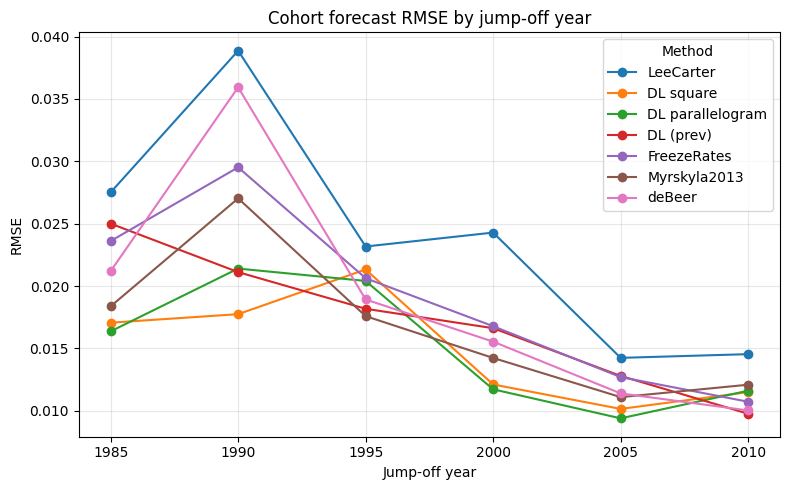

In [235]:
# Plot RMSE by jump-off year for each method
fig, ax = plt.subplots(figsize=(8, 5))
for method in rmse_joy_table.columns:
    ax.plot(rmse_joy_table.index, rmse_joy_table[method], marker='o', label=method)

ax.set_xlabel('Jump-off year')
ax.set_ylabel('RMSE')
ax.set_title('Cohort forecast RMSE by jump-off year')
ax.legend(title='Method')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

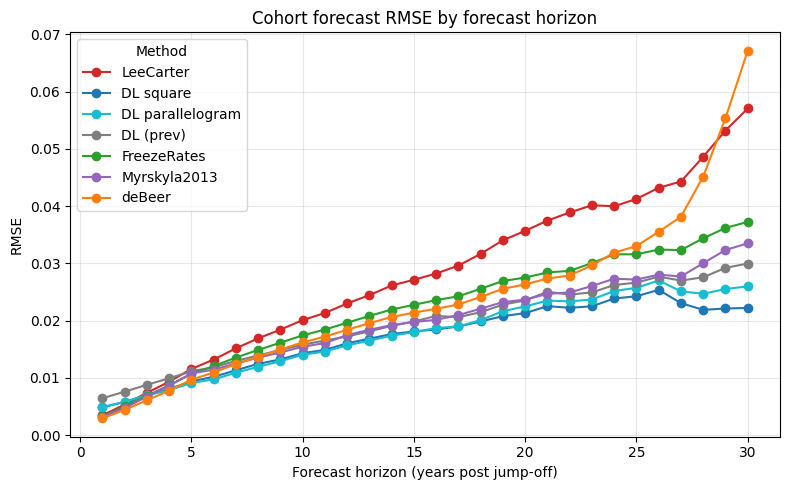

In [236]:
# RMSE by forecast horizon (years post jump-off) for each common-grid method.
# Horizon = period (Year + Age) - JumpOffYear
def rmse_by_horizon(pred_df, obs_df):
    merged = pred_df.merge(
        obs_df[key_cols + ['Rate']], on=key_cols, how='inner',
        suffixes=('_pred', '_obs')
    )
    merged['Horizon'] = merged['Year'] + merged['Age'] - merged['JumpOffYear']
    return merged.groupby('Horizon').apply(
        lambda d: np.sqrt(np.mean((d['Rate_pred'] - d['Rate_obs']) ** 2))
    )

rmse_horizon_table = pd.concat(
    [rmse_by_horizon(M[l]['pred'], M[l]['obs']).rename(l) for l in common_labels],
    axis=1,
)

fig, ax = plt.subplots(figsize=(8, 5))
for label in rmse_horizon_table.columns:
    ax.plot(rmse_horizon_table.index, rmse_horizon_table[label], marker='o',
            color=M[label]['color'], label=label)

ax.set_xlabel('Forecast horizon (years post jump-off)')
ax.set_ylabel('RMSE')
ax.set_title('Cohort forecast RMSE by forecast horizon')
ax.legend(title='Method')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Observed vs. forecast cohort fertility trajectories
# ============================================================

# country index -> country code (for nicer titles)
_geos = np.load('../../data/geos_key.npy', allow_pickle=True)
GEO_NAMES = {int(idx): code for code, idx in _geos}
print(GEO_NAMES)

# Each method: label -> (observed_df, predicted_df, color), built from the registry.
METHODS = {label: (m['obs'], m['pred'], m['color']) for label, m in M.items()}
# NOTE: the black "observed" line uses methods[0]'s obs frame. Keep a DL series
# first so it stays the ACY-observed reference (parallelogram obs is ARDY).


def plot_cohort_forecasts(country, jump_off_year, birth_years,
                          methods=('DL square',)):
    """Trace observed vs. forecast ASFR over age for a selection of cohorts.

    One subplot per cohort (identified by birth `Year`). Observed rates are
    drawn as a solid black line across all ages; each method's forecast is a
    dashed colored line for the post-jump-off ages. A dotted vertical line
    marks the jump-off year, which for a cohort born in `by` sits at
    age = jump_off_year - by.
    """
    n = len(birth_years)
    ncols = min(2, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 4 * nrows),
                             squeeze=False)
    axes = axes.ravel()

    for ax, by in zip(axes, birth_years):
        split_age = jump_off_year - by  # age at which the jump-off year falls

        # --- observed truth (from methods[0]'s obs frame) ---
        obs_df = METHODS[methods[0]][0]
        obs = obs_df[(obs_df['Country'] == country) &
                     (obs_df['JumpOffYear'] == jump_off_year) &
                     (obs_df['Year'] == by)].sort_values('Age')
        if not obs.empty:
            ax.plot(obs['Age'], obs['Rate'], '-', color='black', lw=2,
                    label='Observed (actual)', zorder=5)

        # --- each method's forecast, restricted to post-jump-off ages ---
        for label in methods:
            _, pred_df, color = METHODS[label]
            pred = pred_df[(pred_df['Country'] == country) &
                           (pred_df['JumpOffYear'] == jump_off_year) &
                           (pred_df['Year'] == by)].sort_values('Age')
            fc = pred[(pred['Year'] + pred['Age']) > jump_off_year]
            if not fc.empty:
                ax.plot(fc['Age'], fc['Rate'], '--', color=color, lw=1.8,
                        marker='o', markersize=3, label=f'{label} forecast')

        # --- jump-off marker ---
        if obs['Age'].min() <= split_age <= obs['Age'].max() if not obs.empty else True:
            ax.axvline(split_age, color='gray', ls=':', lw=1.5)
            ax.text(split_age, ax.get_ylim()[1] * 0.98,
                    f' jump-off {jump_off_year}', rotation=90,
                    va='top', ha='left', fontsize=8, color='gray')

        ax.set_title(f'{GEO_NAMES.get(country, country)} — cohort born {by}')
        ax.set_xlabel('Age')
        ax.set_ylabel('ASFR')
        ax.legend(fontsize=8)

    # hide any unused axes
    for ax in axes[len(birth_years):]:
        ax.set_visible(False)

    fig.suptitle(f'Cohort fertility: observed vs. forecast '
                 f'(jump-off {jump_off_year})', fontsize=13)
    plt.tight_layout()
    return fig


fig = plot_cohort_forecasts(
    country=22,
    jump_off_year=1990,
    birth_years=[1955, 1960, 1965, 1970],
    methods=('DL square', 'DL parallelogram', 'LeeCarter', 'FreezeRates', 'Myrskyla2013'),
)
fig.savefig('../../figures/cohort_forecast_trajectories_irl_1990.png', dpi=300,
            bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# Observed vs. forecast cohort fertility trajectories
# ============================================================

# country index -> country code (for nicer titles)
_geos = np.load('../../data/geos_key.npy', allow_pickle=True)
GEO_NAMES = {int(idx): code for code, idx in _geos}
print(GEO_NAMES)

# Each method: label -> (observed_df, predicted_df, color), built from the registry.
METHODS = {label: (m['obs'], m['pred'], m['color']) for label, m in M.items()}
# NOTE: the black "observed" line uses methods[0]'s obs frame. Keep a DL series
# first so it stays the ACY-observed reference (parallelogram obs is ARDY).


def plot_cohort_forecasts(country, jump_off_year, birth_years,
                          methods=('DL square',)):
    """Trace observed vs. forecast ASFR over age for a selection of cohorts.

    One subplot per cohort (identified by birth `Year`). Observed rates are
    drawn as a solid black line across all ages; each method's forecast is a
    dashed colored line for the post-jump-off ages. A dotted vertical line
    marks the jump-off year, which for a cohort born in `by` sits at
    age = jump_off_year - by.
    """
    n = len(birth_years)
    ncols = min(2, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 4 * nrows),
                             squeeze=False)
    axes = axes.ravel()

    for ax, by in zip(axes, birth_years):
        split_age = jump_off_year - by  # age at which the jump-off year falls

        # --- observed truth (from methods[0]'s obs frame) ---
        obs_df = METHODS[methods[0]][0]
        obs = obs_df[(obs_df['Country'] == country) &
                     (obs_df['JumpOffYear'] == jump_off_year) &
                     (obs_df['Year'] == by)].sort_values('Age')
        if not obs.empty:
            ax.plot(obs['Age'], obs['Rate'], '-', color='black', lw=2,
                    label='Observed (actual)', zorder=5)

        # --- each method's forecast, restricted to post-jump-off ages ---
        for label in methods:
            _, pred_df, color = METHODS[label]
            pred = pred_df[(pred_df['Country'] == country) &
                           (pred_df['JumpOffYear'] == jump_off_year) &
                           (pred_df['Year'] == by)].sort_values('Age')
            fc = pred[(pred['Year'] + pred['Age']) > jump_off_year]
            if not fc.empty:
                ax.plot(fc['Age'], fc['Rate'], '--', color=color, lw=1.8,
                        marker='o', markersize=3, label=f'{label} forecast')

        # --- jump-off marker ---
        if obs['Age'].min() <= split_age <= obs['Age'].max() if not obs.empty else True:
            ax.axvline(split_age, color='gray', ls=':', lw=1.5)
            ax.text(split_age, ax.get_ylim()[1] * 0.98,
                    f' jump-off {jump_off_year}', rotation=90,
                    va='top', ha='left', fontsize=8, color='gray')

        ax.set_title(f'{GEO_NAMES.get(country, country)} — cohort born {by}')
        ax.set_xlabel('Age')
        ax.set_ylabel('ASFR')
        ax.legend(fontsize=8)

    # hide any unused axes
    for ax in axes[len(birth_years):]:
        ax.set_visible(False)

    fig.suptitle(f'Cohort fertility: observed vs. forecast '
                 f'(jump-off {jump_off_year})', fontsize=13)
    plt.tight_layout()
    return fig


fig = plot_cohort_forecasts(
    country=35,
    jump_off_year=2010,
    birth_years=[1970, 1975, 1980, 1990],
    methods=('DL square', 'DL parallelogram', 'LeeCarter', 'FreezeRates', 'Myrskyla2013'),
)
#fig.savefig('../../figures/cohort_forecast_trajectories_irl_1990.png', dpi=300,
       #     bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# RMSE by country, common-grid methods (dot plot, sorted by DL square RMSE)
# ============================================================
def _rmse(d):
    return np.sqrt(np.mean((d['Rate_pred'] - d['Rate_obs']) ** 2))

SORT_BY = 'DL square'
plot_labels = common_labels   # models on the shared grid (excludes Schmertmann)

# Merge each method's forecasts with its observed rates on the shared keys
merged_by_model = {
    l: M[l]['pred'].merge(
        M[l]['obs'][key_cols + ['Rate']], on=key_cols, how='inner',
        suffixes=('_pred', '_obs')
    )
    for l in plot_labels
}

rmse_country = pd.DataFrame({
    l: dfm.groupby('Country').apply(_rmse)
    for l, dfm in merged_by_model.items()
})

# for each country, which model has the lowest RMSE -> count wins per model
best_counts = rmse_country.idxmin(axis=1).value_counts()

# sort countries by the reference DL series for readability
rmse_country = rmse_country.sort_values(SORT_BY)
labels = [GEO_NAMES.get(int(c), str(c)) for c in rmse_country.index]
y = np.arange(len(rmse_country))

fig, ax = plt.subplots(figsize=(9, 11))
for l in plot_labels:
    legend_label = f'{l} (best in {best_counts.get(l, 0)})'
    ax.scatter(rmse_country[l], y, color=M[l]['color'], label=legend_label,
               marker=M[l]['marker'], s=40, zorder=3)

# faint connector so each country's spread is easy to read
for yi in y:
    ax.plot(rmse_country.iloc[yi].values, [yi] * rmse_country.shape[1],
            color='lightgray', lw=1, zorder=1)

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=8)
ax.set_ylim(-1, len(y))
ax.set_xlabel('RMSE')
ax.set_title(f'RMSE by country (sorted by {SORT_BY} RMSE)\n'
             f'legend shows # of {len(rmse_country)} countries where each model wins')
ax.legend(title='Model (best in N countries)')
ax.grid(axis='x', ls=':', alpha=0.5)
plt.tight_layout()
plt.savefig('../../figures/rmse_by_country.png', dpi=300, bbox_inches='tight')
plt.show()